<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/Section_5_Working_with_Time_Series_in_Python_Completed_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Relevant Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()

### Loading and Transforming the Data

In [2]:
raw_csv_data = pd.read_csv("/content/sample_data/Index2018.csv") #read directly from Pandas library
df_comp = raw_csv_data.copy() #df_comp --> complete DataFrame

df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.fillna(method='ffill')

/tmp/ipython-input-1923774798.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_comp=df_comp.fillna(method='ffill')




### Removing Surplus Data

In [3]:
df_comp['market_value']=df_comp.spx

In [4]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [5]:
df_comp.describe()

,market_value
count,6277.000000
mean,1288.642547
std,487.868210
min,438.920000
25%,992.715221
50%,1233.761241
75%,1460.250000
max,2872.867839


 White noise - no patterm,

 we cannot preduict white noise

### White Noise

In [6]:
wn = np.random.normal(loc = df.market_value.mean(), scale = df.market_value.std(), size = len(df)) #generation of white noise

In [7]:
df['wn'] = wn

/tmp/ipython-input-672873062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn'] = wn


In [8]:
df.describe()

,market_value,wn
count,5021.000000,5021.000000
mean,1091.651926,1099.965592
std,292.559287,294.221953
min,438.920000,-186.599065
25%,914.620000,907.772251
50%,1144.650000,1102.414460
75%,1316.280729,1299.704302
max,1570.252238,2073.416480


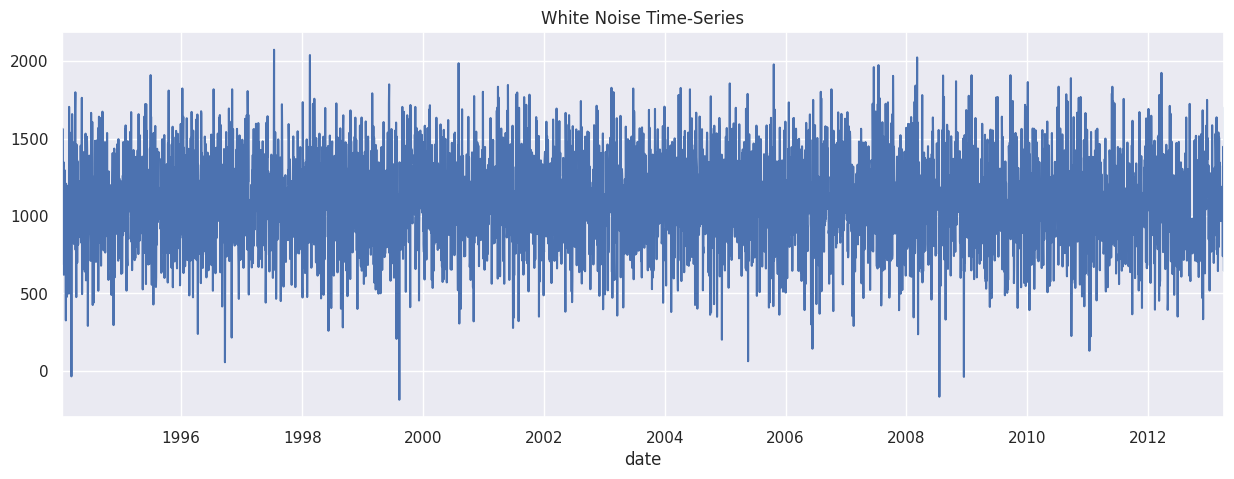

In [9]:
df.wn.plot(figsize = (15,5))
plt.title("White Noise Time-Series", size= 12)
plt.show()

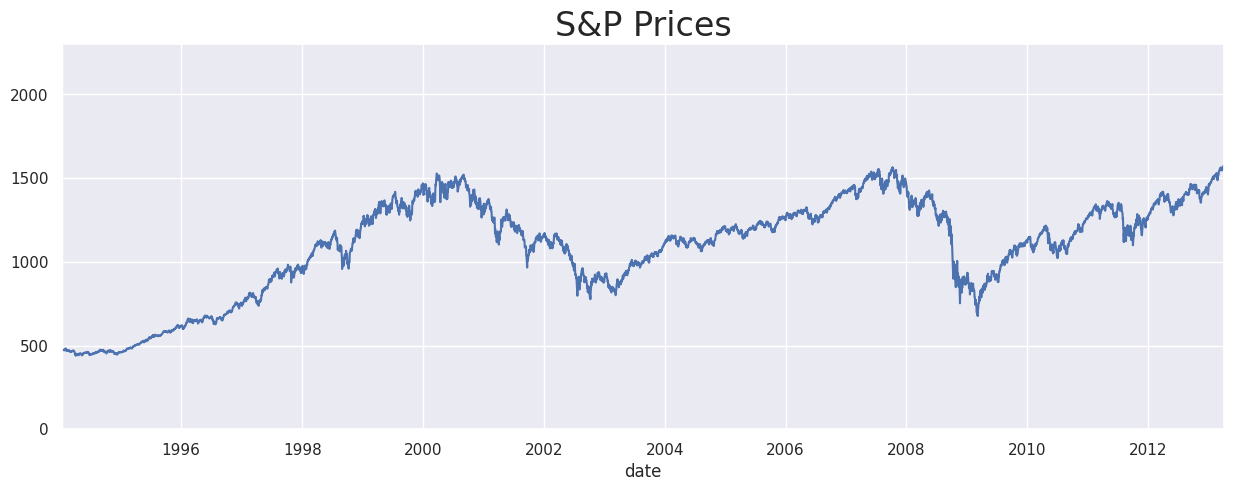

In [10]:
df.market_value.plot(figsize=(15,5))
plt.title("S&P Prices", size = 24)
plt.ylim(0,2300)
plt.show()

### Random Walk

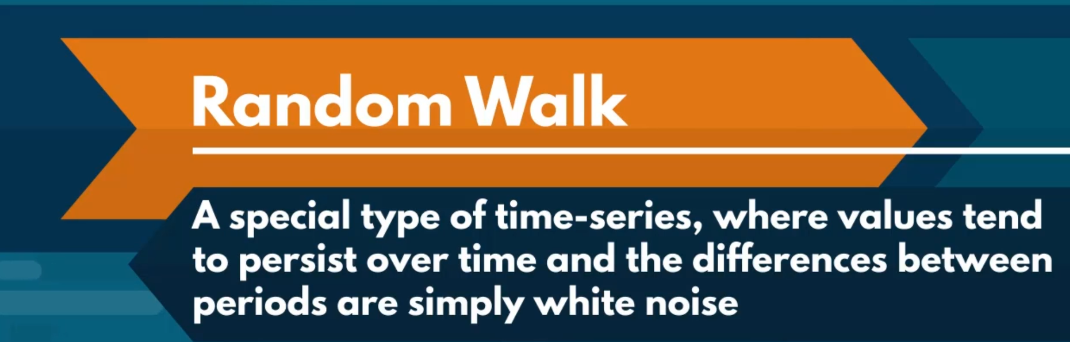

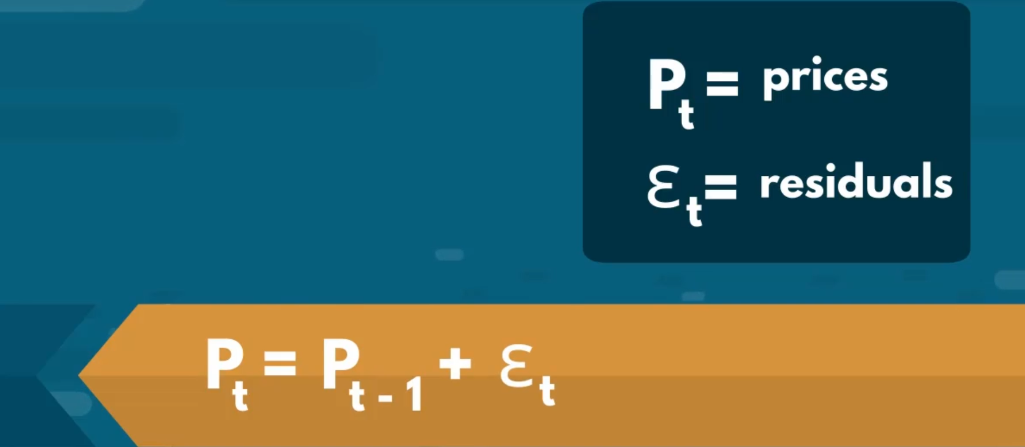

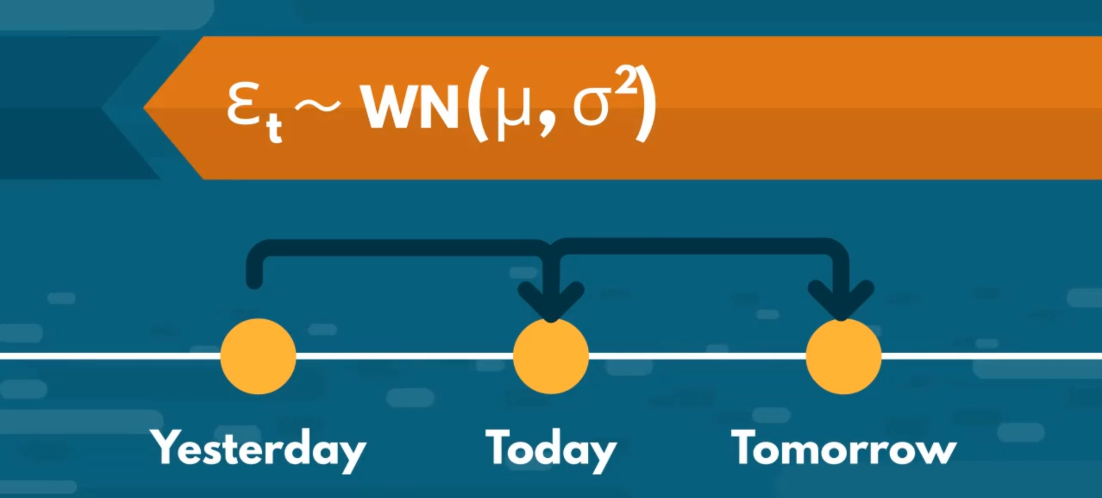

Persystentny

In [11]:
rw = pd.read_csv("/content/sample_data/RandWalk.csv")
rw.date = pd.to_datetime(rw.date, dayfirst=True)  # convert 'date' column to datetime; interpret dates as day-month-year (DD/MM/YY) first
rw.set_index("date", inplace=True)                # set 'date' as the DataFrame index (modifies rw in place)
rw = rw.asfreq("B")                               # enforce business-day frequency (Mon–Fri); missing business days become NaN


In [12]:
rw.describe()

,price
count,5021.000000
mean,1269.944293
std,444.216793
min,585.483034
25%,931.550429
50%,1156.363045
75%,1488.362029
max,2715.508720


In [13]:
rw.head()

,price
date,
1994-01-07,1122.139662
1994-01-10,1080.347860
1994-01-11,1082.095245
1994-01-12,1083.639265
1994-01-13,1067.146255


In [14]:
df.head()

,market_value,wn
date,,
1994-01-07,469.90,872.100392
1994-01-10,475.27,1220.006298
1994-01-11,474.13,693.304087
1994-01-12,474.17,1563.624667
1994-01-13,472.47,1164.882721


In [15]:
df['rw'] = rw.price #add kolumn rw to df - rememeber df is training data

/tmp/ipython-input-3124744209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rw'] = rw.price #add kolumn rw to df - rememeber df is training data


In [16]:
df.head()

,market_value,wn,rw
date,,,
1994-01-07,469.90,872.100392,1122.139662
1994-01-10,475.27,1220.006298,1080.347860
1994-01-11,474.13,693.304087,1082.095245
1994-01-12,474.17,1563.624667,1083.639265
1994-01-13,472.47,1164.882721,1067.146255


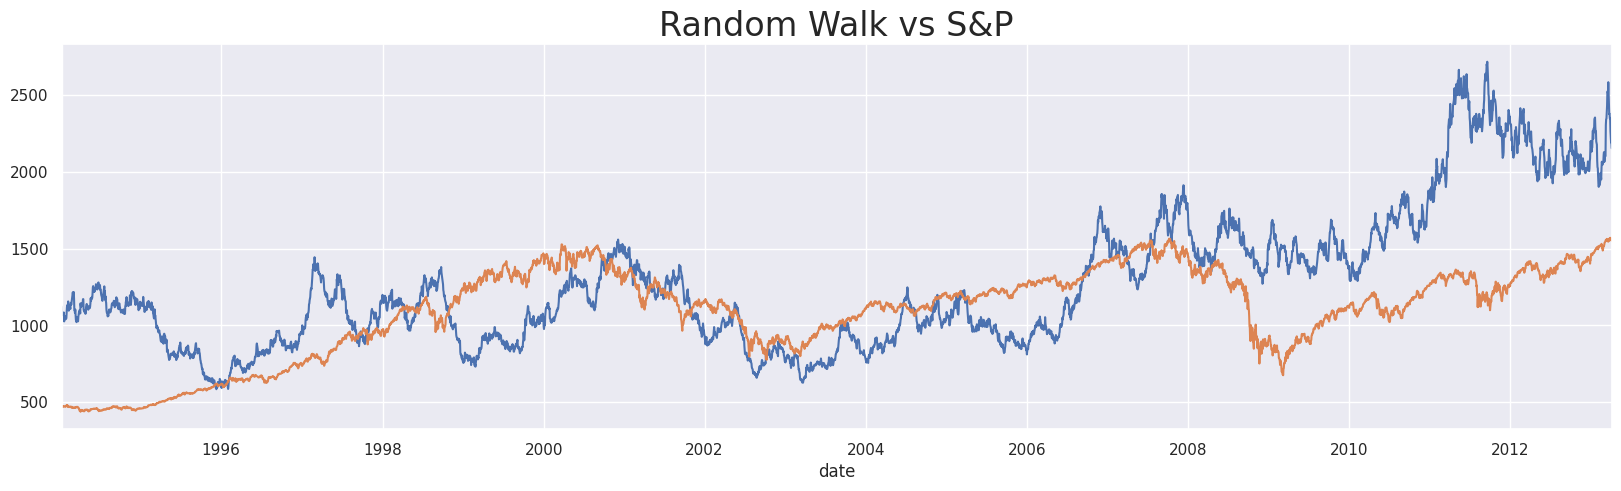

In [17]:
df.rw.plot(figsize = (20,5))
df.market_value.plot()
#df.wn.plot()
plt.title("Random Walk vs S&P", size = 24)
plt.show()

### Stationarity

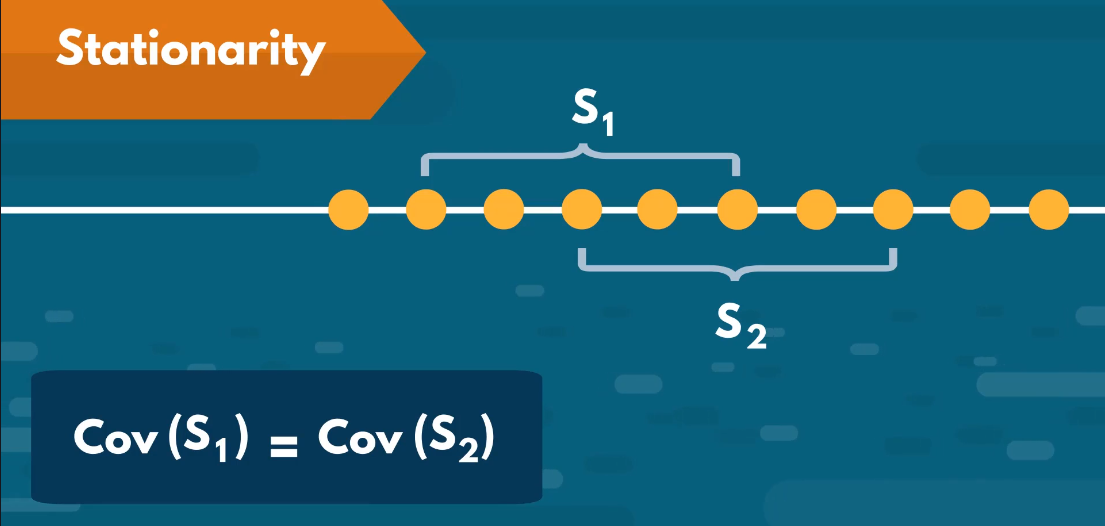

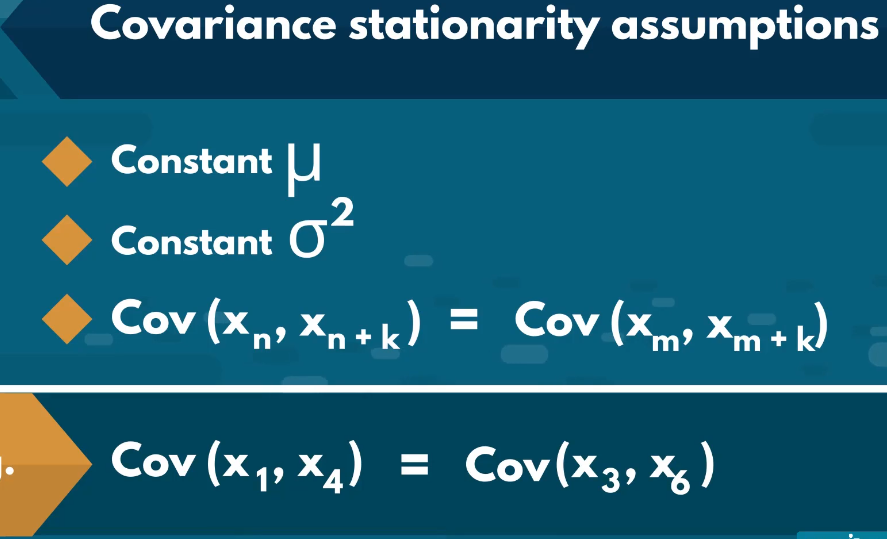

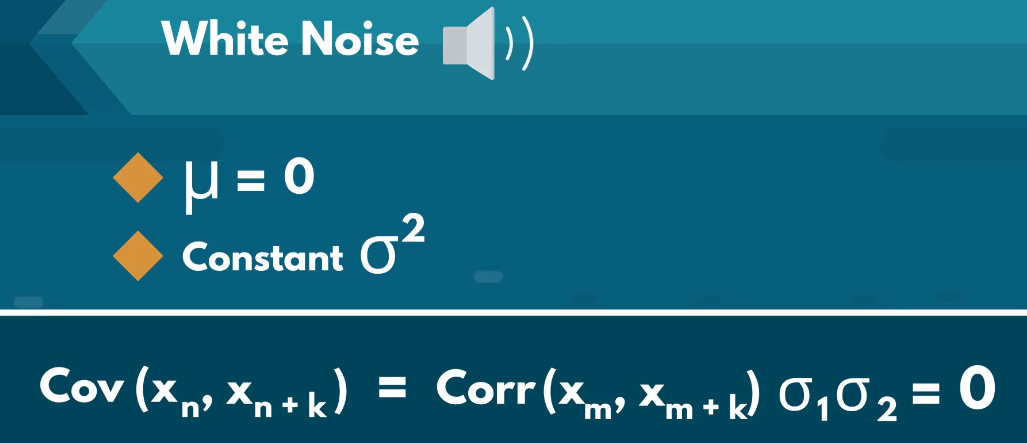

μ = 0
Średnia sygnału = 0. Czyli szum “kręci się” wokół zera, bez trendu.

Constant σ²
Wariancja jest stała w czasie (stała „moc” szumu). Brak zmiany rozrzutu.

Cov(xₙ, xₙ₊ₖ) = 0 dla k ≠ 0
Próbki w różnych chwilach są nieskorelowane: wartość teraz nie mówi nic o wartości za
𝑘
k kroków.
Innymi słowy: brak pamięci.
Szum biały ma kowariancję, autokorelację = 0


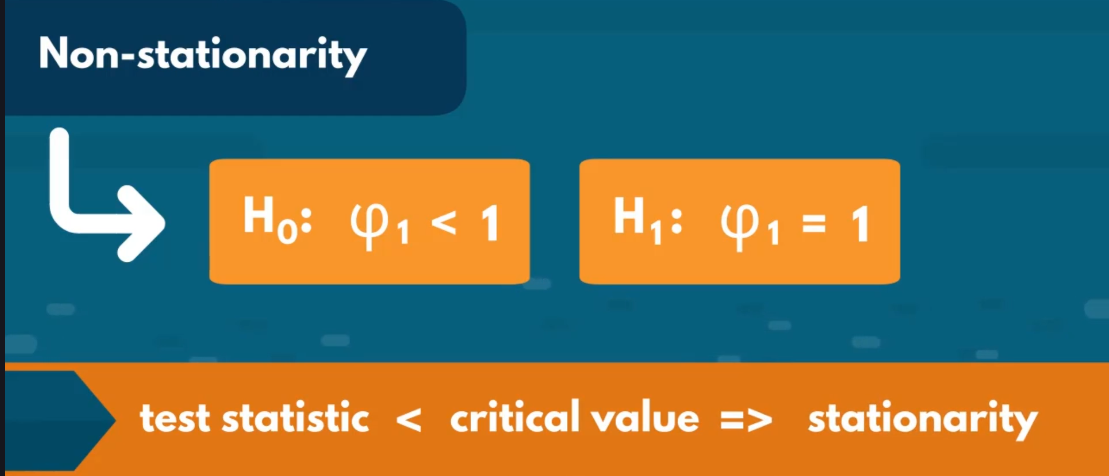

ADF (test statistic < critical value (5%)) => STATIONARY

ADF (test statistic > critical value (5%)) => NON STATIONARY

p value < 0,05 => STATIONARY (H0 is NOK)

p value > 0,05 => NON STATIONARY (H0 is ok)


In [18]:
sts.adfuller(df.market_value)

(np.float64(-1.7369847452352447),
 np.float64(0.4121645696770616),
 18,
 5002,
 {'1%': np.float64(-3.431658008603046),
  '5%': np.float64(-2.862117998412982),
  '10%': np.float64(-2.567077669247375)},
 np.float64(39904.880607487445))

In [19]:
import statsmodels.tsa.stattools as sts  # ADF test lives here

# --- run ADF test (drop NaNs because ADF hates missing values) ---
series = df["market_value"].dropna()                 # clean series (no NaNs)
adf_out = sts.adfuller(series, autolag="AIC")        # ADF test + automatic lag selection by AIC

# --- unpack results ---
adf_stat = adf_out[0]                                # test statistic
p_value = adf_out[1]                                 # p-value
used_lags = adf_out[2]                               # number of lags used
n_obs = adf_out[3]                                   # number of observations used
crit = adf_out[4]                                    # critical values dict: 1%, 5%, 10%
icbest = adf_out[5]                                  # best information criterion value (from autolag)

# --- print raw results ---
print(f"ADF statistic: {adf_stat:.6f}")              # more negative -> stronger evidence vs unit root
print(f"p-value:       {p_value:.6g}")               # key decision number
print(f"used lags:     {used_lags}")                 # how many lagged differences included
print(f"n obs:         {n_obs}")                     # effective sample size
print("critical values:", crit)                      # thresholds for 1%, 5%, 10%
print(f"IC best:       {icbest:.6f}")                # chosen by autolag criterion

# --- interpret stationarity ---
alpha = 0.05                                         # significance level
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 (unit root) -> series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).")

# --- optional: interpretation using critical values (extra sanity check) ---
if adf_stat < crit["5%"]:
    print("Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.")
else:
    print("Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.")


ADF statistic: -1.736985
p-value:       0.412165
used lags:     18
n obs:         5002
critical values: {'1%': np.float64(-3.431658008603046), '5%': np.float64(-2.862117998412982), '10%': np.float64(-2.567077669247375)}
IC best:       39904.880607
Decision @ 0.05: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).
Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.


In [20]:
sts.adfuller(df.wn)

(np.float64(-34.452118412855036),
 0.0,
 3,
 5017,
 {'1%': np.float64(-3.431654095870046),
  '5%': np.float64(-2.8621162697870046),
  '10%': np.float64(-2.5670767490325597)},
 np.float64(70856.62336111929))

In [21]:
import statsmodels.tsa.stattools as sts  # ADF test lives here

# --- run ADF test (drop NaNs because ADF hates missing values) ---
series = df["wn"].dropna()                 # clean series (no NaNs)
adf_out = sts.adfuller(series, autolag="AIC")        # ADF test + automatic lag selection by AIC

# --- unpack results ---
adf_stat = adf_out[0]                                # test statistic
p_value = adf_out[1]                                 # p-value
used_lags = adf_out[2]                               # number of lags used
n_obs = adf_out[3]                                   # number of observations used
crit = adf_out[4]                                    # critical values dict: 1%, 5%, 10%
icbest = adf_out[5]                                  # best information criterion value (from autolag)

# --- print raw results ---
print(f"ADF statistic: {adf_stat:.6f}")              # more negative -> stronger evidence vs unit root
print(f"p-value:       {p_value:.6g}")               # key decision number
print(f"used lags:     {used_lags}")                 # how many lagged differences included
print(f"n obs:         {n_obs}")                     # effective sample size
print("critical values:", crit)                      # thresholds for 1%, 5%, 10%
print(f"IC best:       {icbest:.6f}")                # chosen by autolag criterion

# --- interpret stationarity ---
alpha = 0.05                                         # significance level
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 (unit root) -> series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).")

# --- optional: interpretation using critical values (extra sanity check) ---
if adf_stat < crit["5%"]:
    print("Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.")
else:
    print("Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.")


ADF statistic: -34.452118
p-value:       0
used lags:     3
n obs:         5017
critical values: {'1%': np.float64(-3.431654095870046), '5%': np.float64(-2.8621162697870046), '10%': np.float64(-2.5670767490325597)}
IC best:       70856.623361
Decision @ 0.05: REJECT H0 (unit root) -> series is likely STATIONARY.
Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.


In [22]:
sts.adfuller(df.rw)

(np.float64(-1.3286073927689712),
 np.float64(0.6159849181617387),
 24,
 4996,
 {'1%': np.float64(-3.4316595802782865),
  '5%': np.float64(-2.8621186927706463),
  '10%': np.float64(-2.567078038881065)},
 np.float64(46299.333497595144))

In [23]:
import statsmodels.tsa.stattools as sts  # ADF test lives here

# --- run ADF test (drop NaNs because ADF hates missing values) ---
series = df["rw"].dropna()                 # clean series (no NaNs)
adf_out = sts.adfuller(series, autolag="AIC")        # ADF test + automatic lag selection by AIC

# --- unpack results ---
adf_stat = adf_out[0]                                # test statistic
p_value = adf_out[1]                                 # p-value
used_lags = adf_out[2]                               # number of lags used
n_obs = adf_out[3]                                   # number of observations used
crit = adf_out[4]                                    # critical values dict: 1%, 5%, 10%
icbest = adf_out[5]                                  # best information criterion value (from autolag)

# --- print raw results ---
print(f"ADF statistic: {adf_stat:.6f}")              # more negative -> stronger evidence vs unit root
print(f"p-value:       {p_value:.6g}")               # key decision number
print(f"used lags:     {used_lags}")                 # how many lagged differences included
print(f"n obs:         {n_obs}")                     # effective sample size
print("critical values:", crit)                      # thresholds for 1%, 5%, 10%
print(f"IC best:       {icbest:.6f}")                # chosen by autolag criterion

# --- interpret stationarity ---
alpha = 0.05                                         # significance level
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 (unit root) -> series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).")

# --- optional: interpretation using critical values (extra sanity check) ---
if adf_stat < crit["5%"]:
    print("Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.")
else:
    print("Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.")


ADF statistic: -1.328607
p-value:       0.615985
used lags:     24
n obs:         4996
critical values: {'1%': np.float64(-3.4316595802782865), '5%': np.float64(-2.8621186927706463), '10%': np.float64(-2.567078038881065)}
IC best:       46299.333498
Decision @ 0.05: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).
Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.


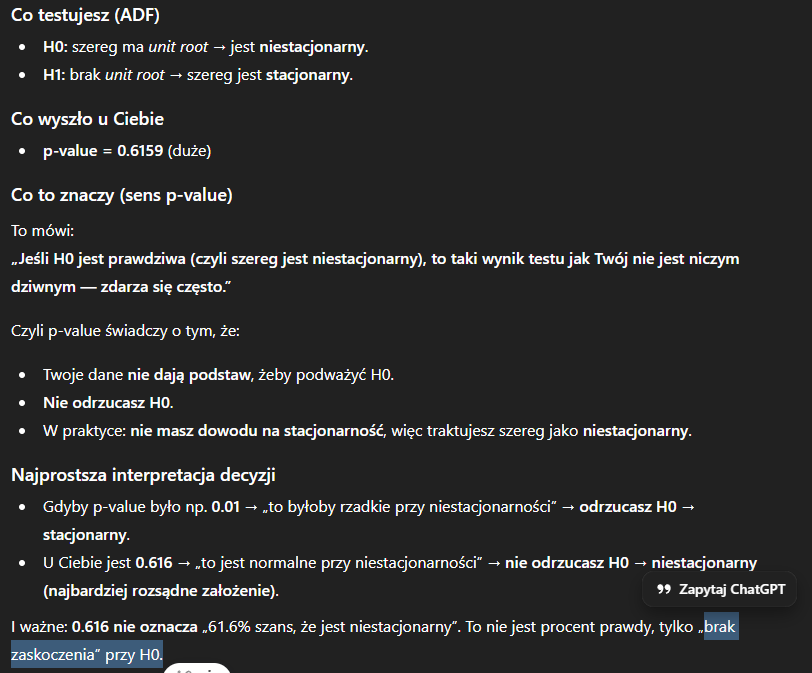

ADF z opcjami

In [43]:
import statsmodels.tsa.stattools as sts  # ADF test (adfuller)

series = df["market_value"].dropna()    # take the signal and remove NaNs

# Meanings + what "stationary" would mean under each option
reg_info = {
    "c":  {
        "meaning": "constant only (drift) included",
        "stationary_means": "stationary around a constant mean (mean-reverting to a level)"
    },
    "ct": {
        "meaning": "constant + linear time trend included",
        "stationary_means": "stationary around a deterministic linear trend (reverting to a trend line)"
    },
    "n":  {
        "meaning": "no constant, no trend included",
        "stationary_means": "stationary around zero (no drift, no trend) — strong assumption"
    }
}

alpha = 0.05  # significance level

for reg in ["c", "ct", "n"]:
    stat, pval, used_lags, nobs, crit, icbest = sts.adfuller(series, regression=reg, autolag="AIC")

    print("\n" + "="*70)
    print(f"ADF option regression='{reg}'")
    print(f"  Meaning: {reg_info[reg]['meaning']}")
    print(f"  If stationary (H1), it would mean: {reg_info[reg]['stationary_means']}")
    print("-"*70)

    print(f"  ADF statistic : {stat:.6f}")
    print(f"  p-value       : {pval:.6g}")
    print(f"  used lags     : {used_lags}")
    print(f"  n obs         : {nobs}")
    print(f"  critical vals : {crit}")
    print(f"  icbest        : {icbest:.6f}")

    # Decision logic for ADF:
    # H0: unit root (non-stationary)
    # H1: stationary (as described above, depending on reg)
    if pval < alpha:
        print(f"  Decision @ {alpha}: REJECT H0 (unit root) -> likely STATIONARY.")
        print(f"  Interpretation: {reg_info[reg]['stationary_means']}")
    else:
        print(f"  Decision @ {alpha}: FAIL TO REJECT H0 -> likely NON-STATIONARY (unit root).")
        print("  Interpretation: test did not provide evidence for stationarity under this specification.")



ADF option regression='c'
  Meaning: constant only (drift) included
  If stationary (H1), it would mean: stationary around a constant mean (mean-reverting to a level)
----------------------------------------------------------------------
  ADF statistic : -1.736985
  p-value       : 0.412165
  used lags     : 18
  n obs         : 5002
  critical vals : {'1%': np.float64(-3.431658008603046), '5%': np.float64(-2.862117998412982), '10%': np.float64(-2.567077669247375)}
  icbest        : 39904.880607
  Decision @ 0.05: FAIL TO REJECT H0 -> likely NON-STATIONARY (unit root).
  Interpretation: test did not provide evidence for stationarity under this specification.

ADF option regression='ct'
  Meaning: constant + linear time trend included
  If stationary (H1), it would mean: stationary around a deterministic linear trend (reverting to a trend line)
----------------------------------------------------------------------
  ADF statistic : -1.980897
  p-value       : 0.6118
  used lags     : 

### Seasonality

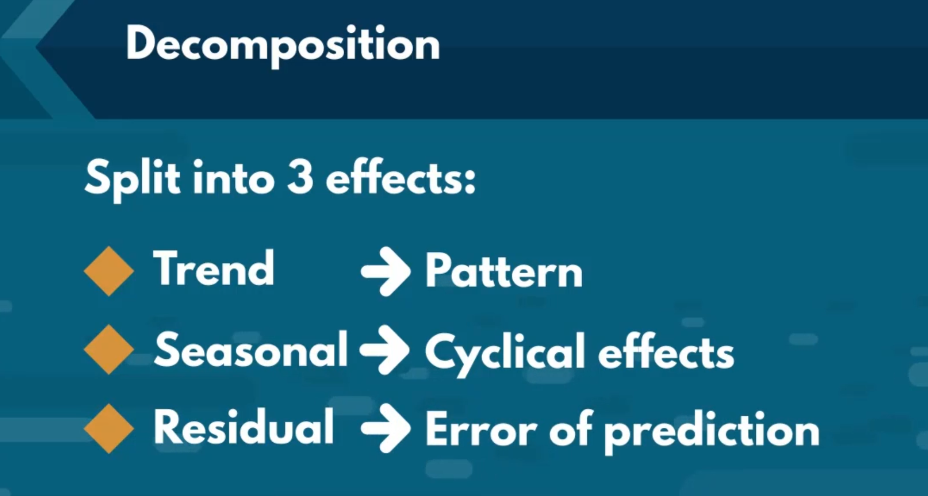

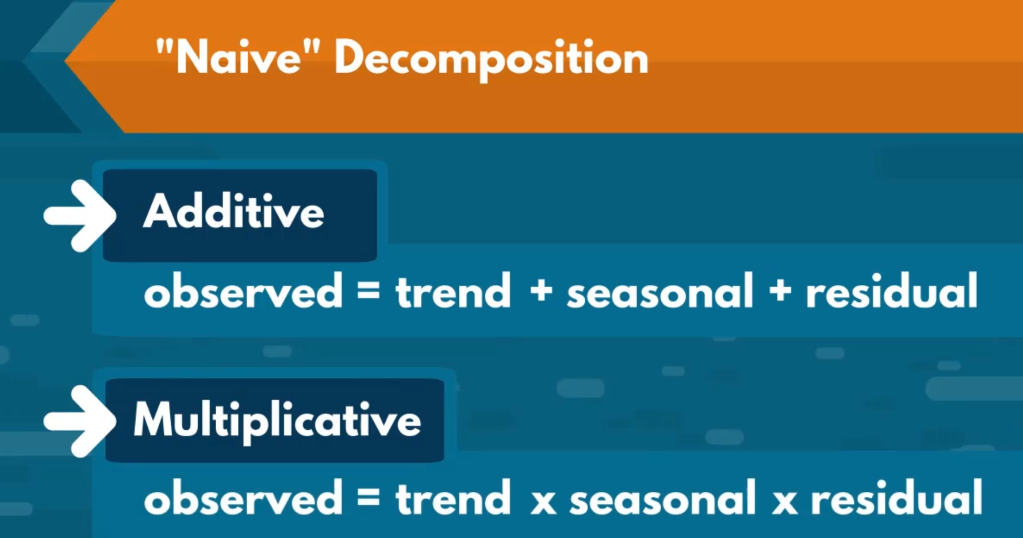

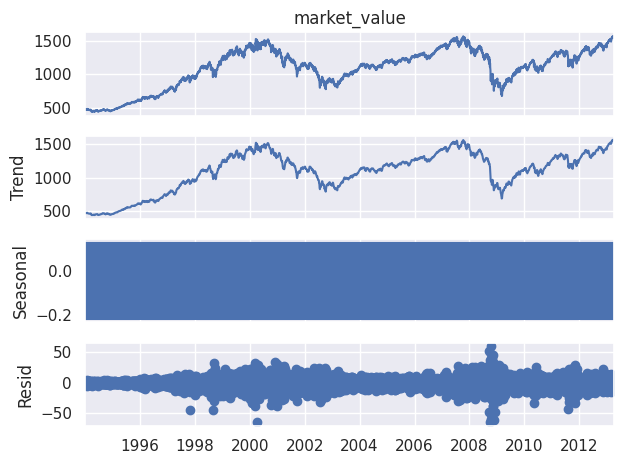

In [24]:
s_dec_additive = seasonal_decompose(df.market_value, model = "additive")
s_dec_additive.plot()
plt.show()

#Additive model

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose  # decomposition
from plotly.subplots import make_subplots                # subplot layout
import plotly.graph_objects as go                        # Plotly traces

# --- prepare a clean, regular time series ---
series = df["market_value"].copy()                       # take the target series
if series.index.inferred_freq is None:
    series = series.asfreq("B")                          # enforce business-day grid if freq is missing

series = series.interpolate("time").ffill().bfill()      # fill gaps (decompose needs no NaNs)

# --- choose seasonal period (IMPORTANT) ---
# Examples:
# - period=5   -> weekly seasonality for business days
# - period=252 -> yearly seasonality for trading days
period = 5

# --- decomposition ---
dec = seasonal_decompose(series, model="additive", period=period)

# --- Plotly figure: 2 rows (QQ not here), 4 panels stacked ---
fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.03,
    subplot_titles=("Observed", "Trend", "Seasonal", "Residual-model error")
)

fig.add_trace(go.Scatter(x=series.index, y=dec.observed, name="Observed", mode="lines"), row=1, col=1)
fig.add_trace(go.Scatter(x=series.index, y=dec.trend,    name="Trend",    mode="lines"), row=2, col=1)
fig.add_trace(go.Scatter(x=series.index, y=dec.seasonal, name="Seasonal", mode="lines"), row=3, col=1)
fig.add_trace(go.Scatter(x=series.index, y=dec.resid,    name="Residual", mode="lines"), row=4, col=1)

fig.update_layout(
    title=f"Seasonal Decomposition (additive) | period={period}",
    height=900,
    showlegend=False,
    hovermode="x unified",
    template="plotly_dark"
)

fig.update_xaxes(rangeslider=dict(visible=True), row=4, col=1)  # range slider at the bottom
fig.show()


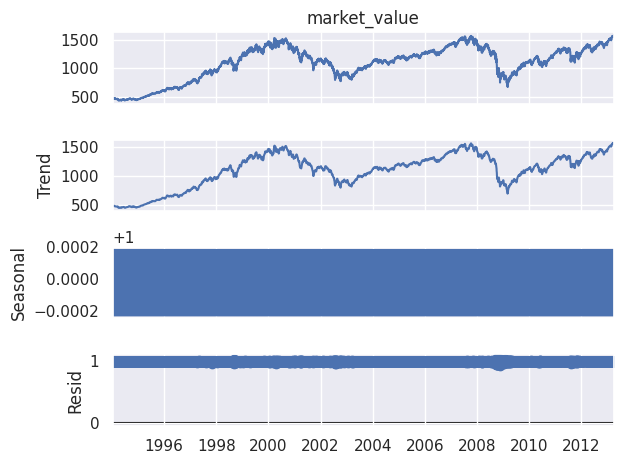

In [26]:
s_dec_multiplicative = seasonal_decompose(df.market_value, model = "multiplicative")
s_dec_multiplicative.plot()
plt.show()

#Multiplicative Model

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose  # decomposition
from plotly.subplots import make_subplots                # subplot layout
import plotly.graph_objects as go                        # Plotly traces

# --- prepare a clean, regular time series ---
series = df["market_value"].copy()                       # take the target series
if series.index.inferred_freq is None:
    series = series.asfreq("B")                          # enforce business-day grid if freq is missing

series = series.interpolate("time").ffill().bfill()      # fill gaps (decompose needs no NaNs)

# --- choose seasonal period (IMPORTANT) ---
# Examples:
# - period=5   -> weekly seasonality for business days
# - period=252 -> yearly seasonality for trading days
period = 5

# --- decomposition ---
dec = seasonal_decompose(series, model="multiplicative", period=period)

# --- Plotly figure: 2 rows (QQ not here), 4 panels stacked ---
fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.03,
    subplot_titles=("Observed", "Trend", "Seasonal", "Residual-model error")
)

fig.add_trace(go.Scatter(x=series.index, y=dec.observed, name="Observed", mode="lines"), row=1, col=1)
fig.add_trace(go.Scatter(x=series.index, y=dec.trend,    name="Trend",    mode="lines"), row=2, col=1)
fig.add_trace(go.Scatter(x=series.index, y=dec.seasonal, name="Seasonal", mode="lines"), row=3, col=1)
fig.add_trace(go.Scatter(x=series.index, y=dec.resid,    name="Residual", mode="lines"), row=4, col=1)

fig.update_layout(
    title=f"Seasonal Decomposition (multiplicative) | period={period}",
    height=900,
    showlegend=False,
    hovermode="x unified",
    template="plotly_dark"
)

fig.update_xaxes(rangeslider=dict(visible=True), row=4, col=1)  # range slider at the bottom
fig.show()


### ACF

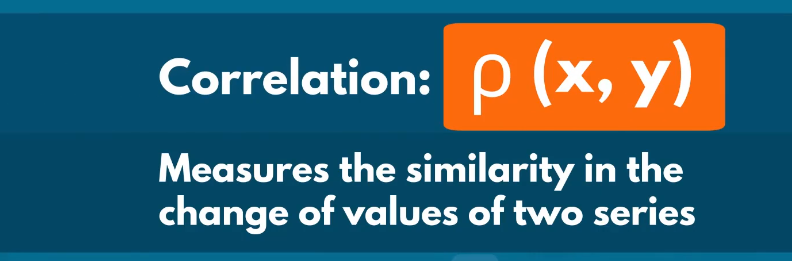

ACF - Auto Correlation Function -> calculates lags

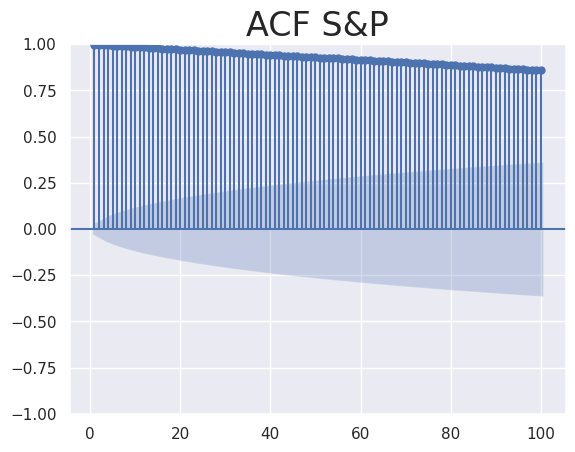

In [28]:
sgt.plot_acf(df.market_value, lags = 100, zero = False)
plt.title("ACF S&P", size = 24)
plt.show()

Market price

In [40]:
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import acf

# --- data (clean) ---
series = df["market_value"].dropna().to_numpy()

# --- ACF + confidence intervals ---
lags = 100
acf_vals, confint = acf(series, nlags=lags, alpha=0.05, fft=True)  # returns ACF and 95% CI for each lag

# if you want zero=False (skip lag 0)
lag_idx = np.arange(1, lags + 1)
acf_plot = acf_vals[1:]
ci_low = confint[1:, 0] - acf_vals[1:]   # lower band around ACF (centered)
ci_high = confint[1:, 1] - acf_vals[1:]  # upper band around ACF (centered)

# --- Build "stem" lines for Plotly (vertical segments) ---
x_stem = np.repeat(lag_idx, 3)
y_stem = np.ravel(np.column_stack([np.zeros_like(acf_plot), acf_plot, np.full_like(acf_plot, np.nan)]))

# --- Plotly figure ---
fig = go.Figure()

# confidence band (shaded)
fig.add_trace(go.Scatter(
    x=np.concatenate([lag_idx, lag_idx[::-1]]),
    y=np.concatenate([ci_high, ci_low[::-1]]),
    fill="toself",
    name="95% CI",
    line=dict(width=0),
    hoverinfo="skip",
    opacity=0.25
))

# zero line
fig.add_trace(go.Scatter(
    x=[0, lags],
    y=[0, 0],
    mode="lines",
    name="0 line",
    hoverinfo="skip",
    line=dict(dash="dash")
))

# stems
fig.add_trace(go.Scatter(
    x=x_stem,
    y=y_stem,
    mode="lines",
    name="ACF",
    line=dict(width=2)
))

# markers on top of stems (optional, looks nice)
fig.add_trace(go.Scatter(
    x=lag_idx,
    y=acf_plot,
    mode="markers",
    name="ACF points",
    marker=dict(size=5)
))

fig.update_layout(
    template="plotly_dark",
    title=f"ACF | market_value | lags={lags}",
    height=550,
    hovermode="x unified",
    showlegend=True
)

fig.update_xaxes(title_text="Lag (k)")
fig.update_yaxes(title_text="Autocorrelation", range=[-1, 1])

fig.show()


Autokorelacja dla wn - white noise

In [30]:
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import acf

# --- data (clean) ---
series = df["wn"].dropna().to_numpy()

# --- ACF + confidence intervals ---
lags = 100
acf_vals, confint = acf(series, nlags=lags, alpha=0.05, fft=True)  # returns ACF and 95% CI for each lag

# if you want zero=False (skip lag 0)
lag_idx = np.arange(1, lags + 1)
acf_plot = acf_vals[1:]
ci_low = confint[1:, 0] - acf_vals[1:]   # lower band around ACF (centered)
ci_high = confint[1:, 1] - acf_vals[1:]  # upper band around ACF (centered)

# --- Build "stem" lines for Plotly (vertical segments) ---
x_stem = np.repeat(lag_idx, 3)
y_stem = np.ravel(np.column_stack([np.zeros_like(acf_plot), acf_plot, np.full_like(acf_plot, np.nan)]))

# --- Plotly figure ---
fig = go.Figure()

# confidence band (shaded)
fig.add_trace(go.Scatter(
    x=np.concatenate([lag_idx, lag_idx[::-1]]),
    y=np.concatenate([ci_high, ci_low[::-1]]),
    fill="toself",
    name="95% CI",
    line=dict(width=0),
    hoverinfo="skip",
    opacity=0.25
))

# zero line
fig.add_trace(go.Scatter(
    x=[0, lags],
    y=[0, 0],
    mode="lines",
    name="0 line",
    hoverinfo="skip",
    line=dict(dash="dash")
))

# stems
fig.add_trace(go.Scatter(
    x=x_stem,
    y=y_stem,
    mode="lines",
    name="ACF",
    line=dict(width=2)
))

# markers on top of stems (optional, looks nice)
fig.add_trace(go.Scatter(
    x=lag_idx,
    y=acf_plot,
    mode="markers",
    name="ACF points",
    marker=dict(size=5)
))

fig.update_layout(
    template="plotly_dark",
    title=f"ACF | wn | lags={lags}",
    height=550,
    hovermode="x unified",
    showlegend=True
)

fig.update_xaxes(title_text="Lag (k)")
fig.update_yaxes(title_text="Autocorrelation", range=[-1, 1])

fig.show()


Random Walk

In [31]:
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import acf

# --- data (clean) ---
series = df["rw"].dropna().to_numpy()

# --- ACF + confidence intervals ---
lags = 100
acf_vals, confint = acf(series, nlags=lags, alpha=0.05, fft=True)  # returns ACF and 95% CI for each lag

# if you want zero=False (skip lag 0)
lag_idx = np.arange(1, lags + 1)
acf_plot = acf_vals[1:]
ci_low = confint[1:, 0] - acf_vals[1:]   # lower band around ACF (centered)
ci_high = confint[1:, 1] - acf_vals[1:]  # upper band around ACF (centered)

# --- Build "stem" lines for Plotly (vertical segments) ---
x_stem = np.repeat(lag_idx, 3)
y_stem = np.ravel(np.column_stack([np.zeros_like(acf_plot), acf_plot, np.full_like(acf_plot, np.nan)]))

# --- Plotly figure ---
fig = go.Figure()

# confidence band (shaded)
fig.add_trace(go.Scatter(
    x=np.concatenate([lag_idx, lag_idx[::-1]]),
    y=np.concatenate([ci_high, ci_low[::-1]]),
    fill="toself",
    name="95% CI",
    line=dict(width=0),
    hoverinfo="skip",
    opacity=0.25
))

# zero line
fig.add_trace(go.Scatter(
    x=[0, lags],
    y=[0, 0],
    mode="lines",
    name="0 line",
    hoverinfo="skip",
    line=dict(dash="dash")
))

# stems
fig.add_trace(go.Scatter(
    x=x_stem,
    y=y_stem,
    mode="lines",
    name="ACF",
    line=dict(width=2)
))

# markers on top of stems (optional, looks nice)
fig.add_trace(go.Scatter(
    x=lag_idx,
    y=acf_plot,
    mode="markers",
    name="ACF points",
    marker=dict(size=5)
))

fig.update_layout(
    template="plotly_dark",
    title=f"ACF | rw | lags={lags}",
    height=550,
    hovermode="x unified",
    showlegend=True
)

fig.update_xaxes(title_text="Lag (k)")
fig.update_yaxes(title_text="Autocorrelation", range=[-1, 1])

fig.show()


### PACF

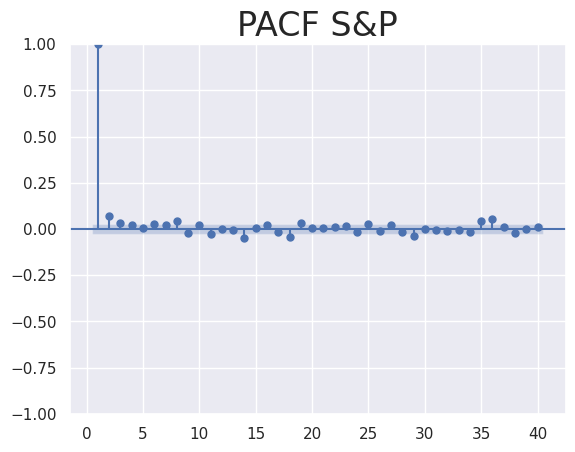

In [32]:
sgt.plot_pacf(df.market_value, lags = 40, zero = False, method = ('ols'))
plt.title("PACF S&P", size = 24)
plt.show()

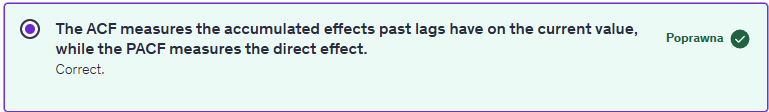

In [33]:
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import pacf

# --- data (clean) ---
series = df["market_value"].dropna().to_numpy()

# --- PACF + confidence intervals (approx) ---
lags = 100
pacf_vals, confint = pacf(series, nlags=lags, method="ols", alpha=0.05)  # returns PACF and 95% CI

# zero=False -> skip lag 0
lag_idx = np.arange(1, lags + 1)
pacf_plot = pacf_vals[1:]
ci_low = confint[1:, 0] - pacf_vals[1:]   # lower band around PACF (centered)
ci_high = confint[1:, 1] - pacf_vals[1:]  # upper band around PACF (centered)

# --- Build "stem" lines for Plotly (vertical segments) ---
x_stem = np.repeat(lag_idx, 3)
y_stem = np.ravel(np.column_stack([np.zeros_like(pacf_plot), pacf_plot, np.full_like(pacf_plot, np.nan)]))

# --- Plotly figure ---
fig = go.Figure()

# confidence band (shaded)
fig.add_trace(go.Scatter(
    x=np.concatenate([lag_idx, lag_idx[::-1]]),
    y=np.concatenate([ci_high, ci_low[::-1]]),
    fill="toself",
    name="95% CI",
    line=dict(width=0),
    hoverinfo="skip",
    opacity=0.25
))

# zero line
fig.add_trace(go.Scatter(
    x=[0, lags],
    y=[0, 0],
    mode="lines",
    name="0 line",
    hoverinfo="skip",
    line=dict(dash="dash")
))

# stems
fig.add_trace(go.Scatter(
    x=x_stem,
    y=y_stem,
    mode="lines",
    name="PACF",
    line=dict(width=2)
))

# markers on top of stems (optional)
fig.add_trace(go.Scatter(
    x=lag_idx,
    y=pacf_plot,
    mode="markers",
    name="PACF points",
    marker=dict(size=6)
))

fig.update_layout(
    template="plotly_dark",
    title=f"PACF | market_value | lags={lags} | method=OLS",
    height=550,
    hovermode="x unified",
    showlegend=True
)

fig.update_xaxes(title_text="Lag (k)")
fig.update_yaxes(title_text="Partial Autocorrelation", range=[-1, 1])

fig.show()


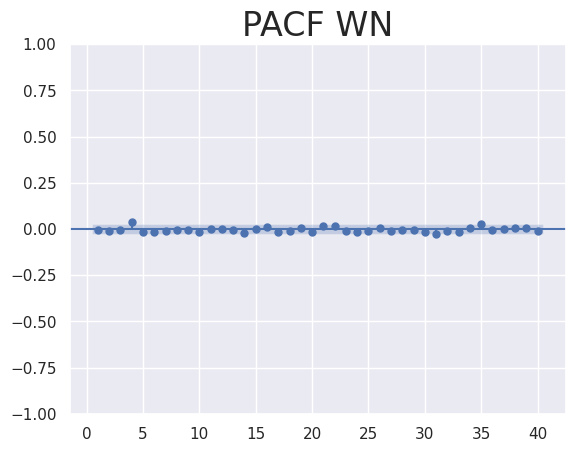

In [34]:
sgt.plot_pacf(df.wn, lags = 40, zero = False, method = ('ols'))
plt.title("PACF WN", size = 24)
plt.show()

In [35]:
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import pacf

# --- data (clean) ---
series = df["wn"].dropna().to_numpy()

# --- PACF + confidence intervals (approx) ---
lags = 100
pacf_vals, confint = pacf(series, nlags=lags, method="ols", alpha=0.05)  # returns PACF and 95% CI

# zero=False -> skip lag 0
lag_idx = np.arange(1, lags + 1)
pacf_plot = pacf_vals[1:]
ci_low = confint[1:, 0] - pacf_vals[1:]   # lower band around PACF (centered)
ci_high = confint[1:, 1] - pacf_vals[1:]  # upper band around PACF (centered)

# --- Build "stem" lines for Plotly (vertical segments) ---
x_stem = np.repeat(lag_idx, 3)
y_stem = np.ravel(np.column_stack([np.zeros_like(pacf_plot), pacf_plot, np.full_like(pacf_plot, np.nan)]))

# --- Plotly figure ---
fig = go.Figure()

# confidence band (shaded)
fig.add_trace(go.Scatter(
    x=np.concatenate([lag_idx, lag_idx[::-1]]),
    y=np.concatenate([ci_high, ci_low[::-1]]),
    fill="toself",
    name="95% CI",
    line=dict(width=0),
    hoverinfo="skip",
    opacity=0.25
))

# zero line
fig.add_trace(go.Scatter(
    x=[0, lags],
    y=[0, 0],
    mode="lines",
    name="0 line",
    hoverinfo="skip",
    line=dict(dash="dash")
))

# stems
fig.add_trace(go.Scatter(
    x=x_stem,
    y=y_stem,
    mode="lines",
    name="PACF",
    line=dict(width=2)
))

# markers on top of stems (optional)
fig.add_trace(go.Scatter(
    x=lag_idx,
    y=pacf_plot,
    mode="markers",
    name="PACF points",
    marker=dict(size=6)
))

fig.update_layout(
    template="plotly_dark",
    title=f"PACF | wn | lags={lags} | method=OLS",
    height=550,
    hovermode="x unified",
    showlegend=True
)

fig.update_xaxes(title_text="Lag (k)")
fig.update_yaxes(title_text="Partial Autocorrelation", range=[-1, 1])

fig.show()


In [36]:
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import pacf

# --- data (clean) ---
series = df["rw"].dropna().to_numpy()

# --- PACF + confidence intervals (approx) ---
lags = 40
pacf_vals, confint = pacf(series, nlags=lags, method="ols", alpha=0.05)  # returns PACF and 95% CI

# zero=False -> skip lag 0
lag_idx = np.arange(1, lags + 1)
pacf_plot = pacf_vals[1:]
ci_low = confint[1:, 0] - pacf_vals[1:]   # lower band around PACF (centered)
ci_high = confint[1:, 1] - pacf_vals[1:]  # upper band around PACF (centered)

# --- Build "stem" lines for Plotly (vertical segments) ---
x_stem = np.repeat(lag_idx, 3)
y_stem = np.ravel(np.column_stack([np.zeros_like(pacf_plot), pacf_plot, np.full_like(pacf_plot, np.nan)]))

# --- Plotly figure ---
fig = go.Figure()

# confidence band (shaded)
fig.add_trace(go.Scatter(
    x=np.concatenate([lag_idx, lag_idx[::-1]]),
    y=np.concatenate([ci_high, ci_low[::-1]]),
    fill="toself",
    name="95% CI",
    line=dict(width=0),
    hoverinfo="skip",
    opacity=0.25
))

# zero line
fig.add_trace(go.Scatter(
    x=[0, lags],
    y=[0, 0],
    mode="lines",
    name="0 line",
    hoverinfo="skip",
    line=dict(dash="dash")
))

# stems
fig.add_trace(go.Scatter(
    x=x_stem,
    y=y_stem,
    mode="lines",
    name="PACF",
    line=dict(width=2)
))

# markers on top of stems (optional)
fig.add_trace(go.Scatter(
    x=lag_idx,
    y=pacf_plot,
    mode="markers",
    name="PACF points",
    marker=dict(size=6)
))

fig.update_layout(
    template="plotly_dark",
    title=f"PACF | rw | lags={lags} | method=OLS",
    height=550,
    hovermode="x unified",
    showlegend=True
)

fig.update_xaxes(title_text="Lag (k)")
fig.update_yaxes(title_text="Partial Autocorrelation", range=[-1, 1])

fig.show()


Test KPSS

In [38]:
import numpy as np
from statsmodels.tsa.stattools import kpss

# --- data (clean) ---
series = df["wn"].dropna().to_numpy()

# --- KPSS test ---
# regression="c"  -> test level-stationarity (around a constant)
# regression="ct" -> test trend-stationarity (around a trend)
kpss_stat, p_value, lags_used, crit = kpss(series, regression="c", nlags="auto")

# --- print results ---
print(f"KPSS statistic: {kpss_stat:.6f}")
print(f"p-value:        {p_value:.6g}")
print(f"lags used:      {lags_used}")
print("critical values:", crit)

# --- interpret stationarity ---
alpha = 0.05
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 -> series is likely NON-STATIONARY (or has a trend).")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely STATIONARY (around a constant).")


KPSS statistic: 0.363621
p-value:        0.092836
lags used:      6
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Decision @ 0.05: FAIL TO REJECT H0 -> series is likely STATIONARY (around a constant).
